Copyright (c) MONAI Consortium  
Licensed under the Apache License, Version 2.0 (the "License");  
you may not use this file except in compliance with the License.  
You may obtain a copy of the License at  
&nbsp;&nbsp;&nbsp;&nbsp;http://www.apache.org/licenses/LICENSE-2.0  
Unless required by applicable law or agreed to in writing, software  
distributed under the License is distributed on an "AS IS" BASIS,  
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.  
See the License for the specific language governing permissions and  
limitations under the License.

# MONAI 101 tutorial

In this tutorial, we will introduce how simple it can be to run an end-to-end classification pipeline with MONAI.

These steps will be included in this tutorial, and each of them will take only a few lines of code:
- Dataset download
- Data pre-processing
- Define a DenseNet-121 and run training
- Check the results on test dataset

This tutorial will use about 7GB of GPU memory and 10 minutes to run.

## Setup imports

In [ ]:
import os
import tempfile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from bioMONAI.data import *
from bioMONAI.core import *
from bioMONAI.core import Path
from bioMONAI.metrics import accuracy
from bioMONAI.losses import CrossEntropyLossFlat
from bioMONAI.data import CategoryBlock, parent_label
from bioMONAI.transforms import ScaleIntensity

from monai.networks.nets import DenseNet121
from monai.utils import set_determinism

from monai.apps import MedNISTDataset

## Setup data directory

You can specify a directory.  
This allows you to save results and reuse downloads.  
If not specified a temporary directory will be used.

In [ ]:
base_directory = '../../_data/'
if base_directory is not None:
    os.makedirs(base_directory, exist_ok=True)
root_dir = tempfile.mkdtemp() if base_directory is None else base_directory
print(root_dir)

../../_data/


## Use MONAI transforms to preprocess data

Medical images require specialized methods for I/O, preprocessing, and augmentation.
They often follow specific formats, are handled with specific protocols, and the data arrays are often high-dimensional.

In this example, we will perform image loading, data format verification, and intensity scaling with three `monai.transforms` listed below, and compose a pipeline ready to be used in next steps.

## Prepare datasets using MONAI Apps

We use `MedNISTDataset` in MONAI Apps to download a dataset to the specified directory and perform the pre-processing steps in the `monai.transforms` compose.

The MedNIST dataset was gathered from several sets from [TCIA](https://wiki.cancerimagingarchive.net/display/Public/Data+Usage+Policies+and+Restrictions),
[the RSNA Bone Age Challenge](http://rsnachallenges.cloudapp.net/competitions/4),
and [the NIH Chest X-ray dataset](https://cloud.google.com/healthcare/docs/resources/public-datasets/nih-chest).

The dataset is kindly made available by [Dr. Bradley J. Erickson M.D., Ph.D.](https://www.mayo.edu/research/labs/radiology-informatics/overview) (Department of Radiology, Mayo Clinic)
under the Creative Commons [CC BY-SA 4.0 license](https://creativecommons.org/licenses/by-sa/4.0/).

If you use the MedNIST dataset, please acknowledge the source. 

In [ ]:
from monai.transforms import LoadImageD, EnsureChannelFirstD, ScaleIntensityD, Compose

transform = Compose(
    [
        LoadImageD(keys="image", image_only=True),
        EnsureChannelFirstD(keys="image"),
        ScaleIntensityD(keys="image"),
    ]
)

In [ ]:
train_ds = MedNISTDataset(root_dir=root_dir, transform=transform, section="training", download=False)
val_ds = MedNISTDataset(root_dir=root_dir, transform=transform, section="validation", download=False)
test_ds = MedNISTDataset(root_dir=root_dir, transform=transform, section="test", download=False)

Loading dataset: 100%|██████████| 5895/5895 [00:04<00:00, 1361.04it/s]


In [ ]:
data_ops = {
    'x_keys': 'image',
    'y_keys': 'label', 
    'bs': 512,
    'shuffle': True,
    'vocab': ['AbdomenCT','BreastMRI','ChestCT','CXR','Hand','HeadCT'],
    'show_summary': True,
}

data = BioDataLoaders.from_monai(train_ds, val_ds, **data_ops)


Train DataLoader
----------------
Dataset size : 47164
Batch size   : 512
Batches      : 93
Classes      : ['AbdomenCT', 'BreastMRI', 'ChestCT', 'CXR', 'Hand', 'HeadCT']

Batch structure:
  [0] shape=(512, 1, 64, 64) dtype=torch.float32 ~8.00 MB
  [1] shape=(512,) dtype=torch.int64 ~0.00 MB
Approx batch memory: 8.00 MB

Valid DataLoader
----------------
Dataset size : 5895
Batch size   : 1024
Batches      : 6
Classes      : ['AbdomenCT', 'BreastMRI', 'ChestCT', 'CXR', 'Hand', 'HeadCT']

Batch structure:
  [0] shape=(1024, 1, 64, 64) dtype=torch.float32 ~16.00 MB
  [1] shape=(1024,) dtype=torch.int64 ~0.01 MB
Approx batch memory: 16.01 MB


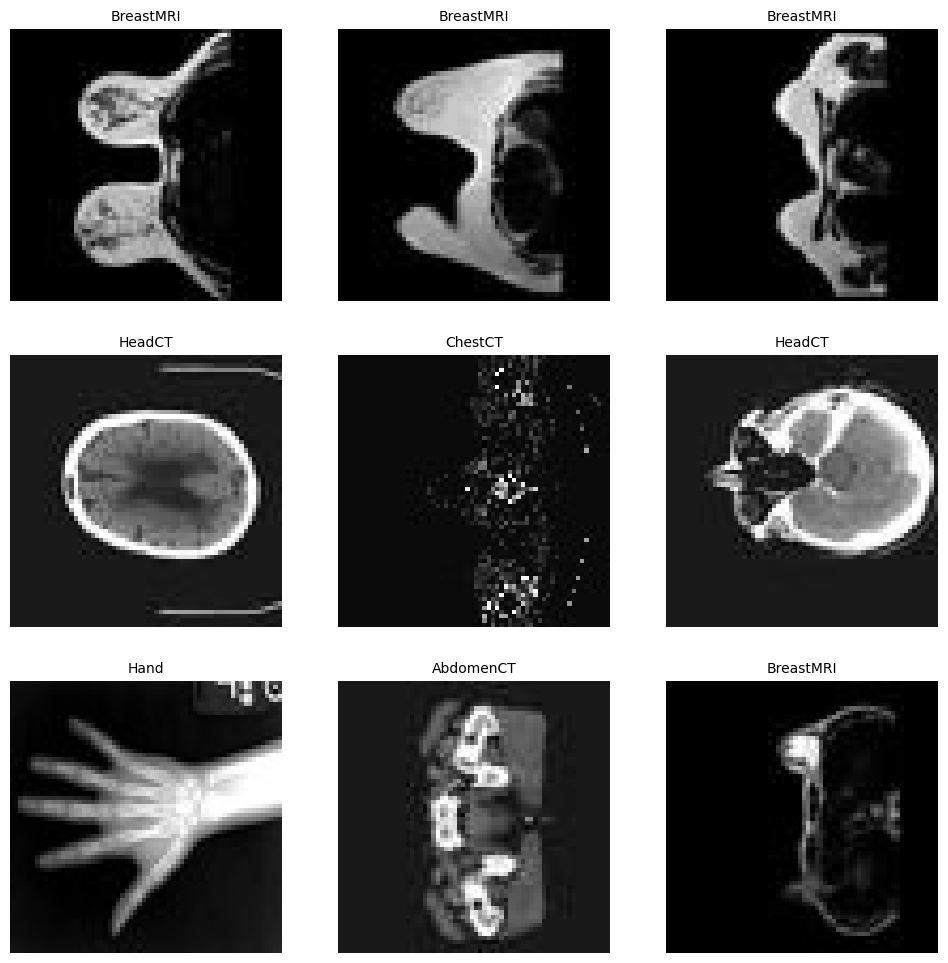

In [ ]:
data.show_batch()

## Define a network and a supervised trainer

To train a model that can perform the classification task, we will use the DenseNet-121 which is known for its performance on the ImageNet dataset.

For a typical supervised training workflow, MONAI provides `SupervisedTrainer` to define the hyper-parameters.

In [ ]:
max_epochs = 5
device = get_device()
model = DenseNet121(spatial_dims=2, in_channels=1, out_channels=6)
loss_function = CrossEntropyLossFlat()
metrics = [accuracy]

trainer = fastTrainer(data, model, loss_fn=loss_function, metrics=metrics, show_summary=False, lr=1e-5)

## Run the training

epoch,train_loss,valid_loss,accuracy,time
0,0.695648,0.351674,0.967430,00:15
1,0.247904,0.118539,0.984733,00:13
2,0.104032,0.061083,0.991858,00:11
3,0.053527,0.036639,0.994063,00:11
4,0.031889,0.023484,0.995589,00:11


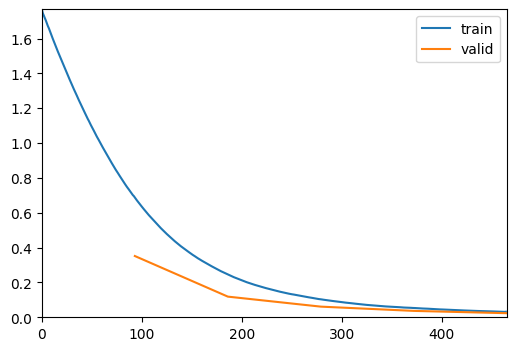

In [ ]:
trainer.fit(max_epochs)

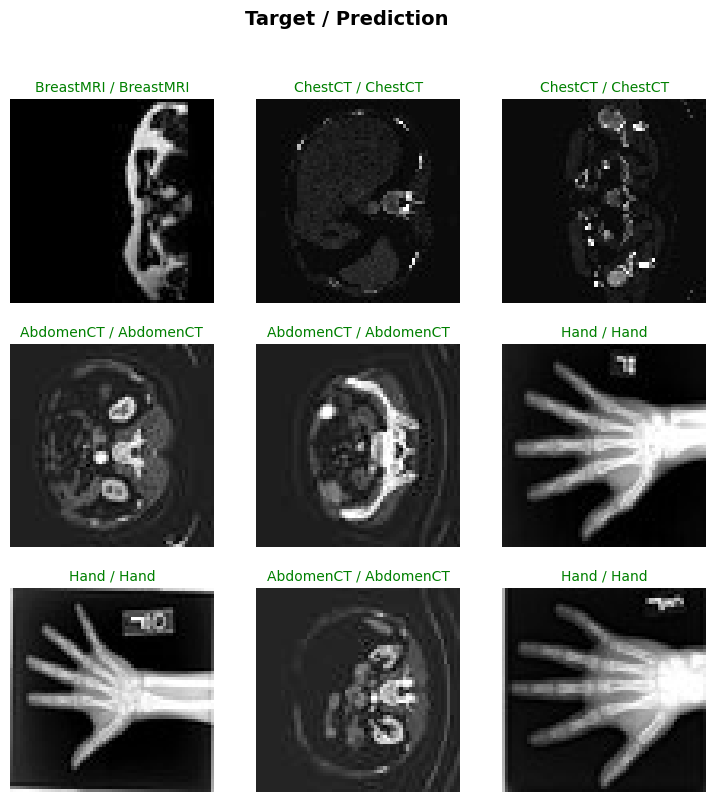

In [ ]:
trainer.show_results()

## Check the prediction on the test dataset

              precision    recall  f1-score   support

   AbdomenCT       0.98      1.00      0.99       971
   BreastMRI       1.00      0.99      0.99       905
         CXR       1.00      1.00      1.00      1048
     ChestCT       1.00      1.00      1.00       994
        Hand       1.00      1.00      1.00      1005
      HeadCT       1.00      0.99      1.00       972

    accuracy                           1.00      5895
   macro avg       1.00      1.00      1.00      5895
weighted avg       1.00      1.00      1.00      5895




Most Confused Classes:


,Actual Class,Predicted Class,Count
0,BreastMRI,AbdomenCT,13
1,HeadCT,AbdomenCT,5
2,CXR,Hand,4
3,AbdomenCT,HeadCT,1
4,CXR,BreastMRI,1
5,Hand,BreastMRI,1
6,Hand,CXR,1


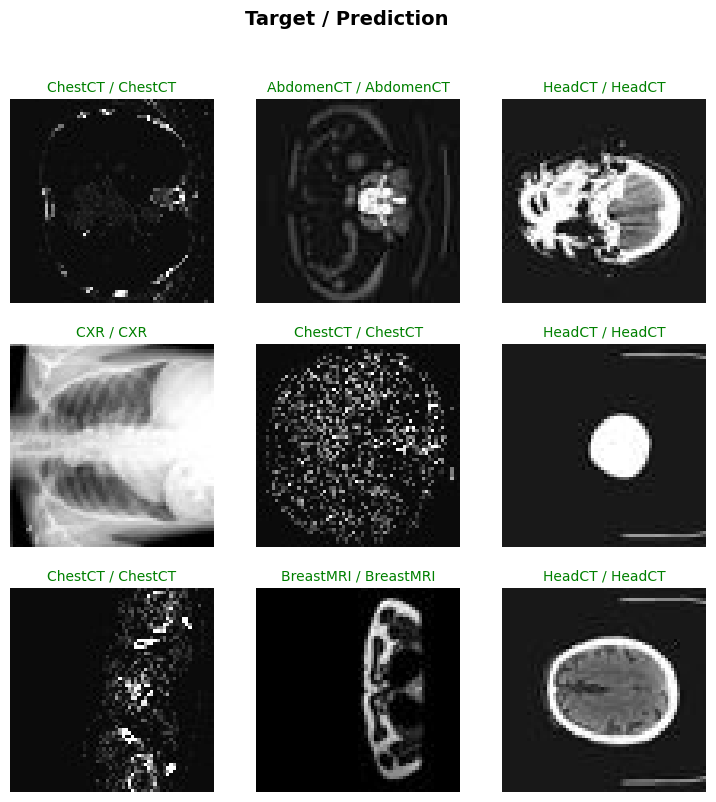

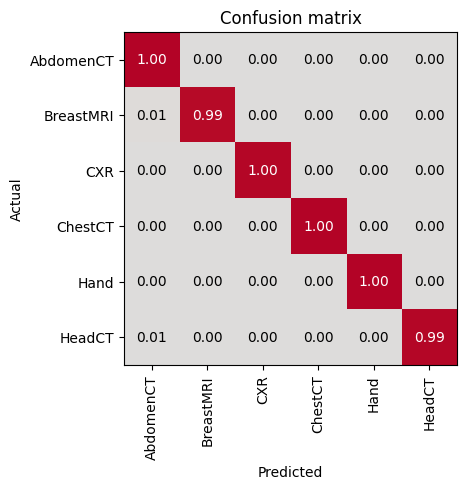

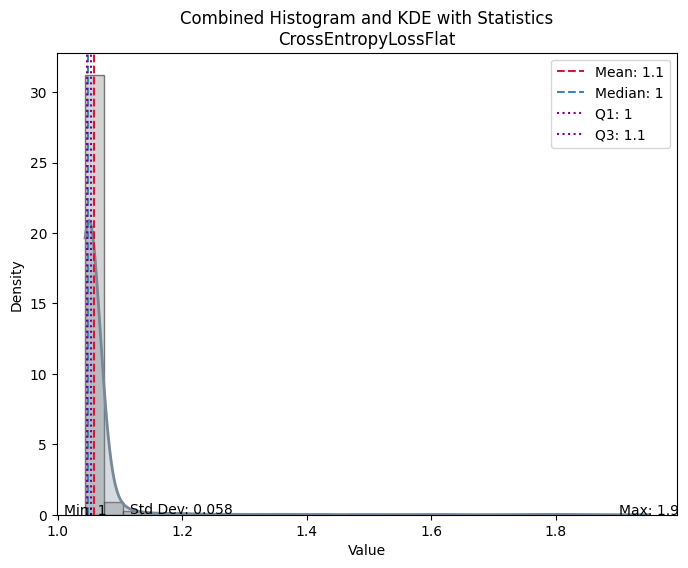

,Value
CrossEntropyLossFlat,
Mean,1.058869
Median,1.049107
Standard Deviation,0.057837
Min,1.043915
Max,1.949105
Q1,1.047073
Q3,1.053043


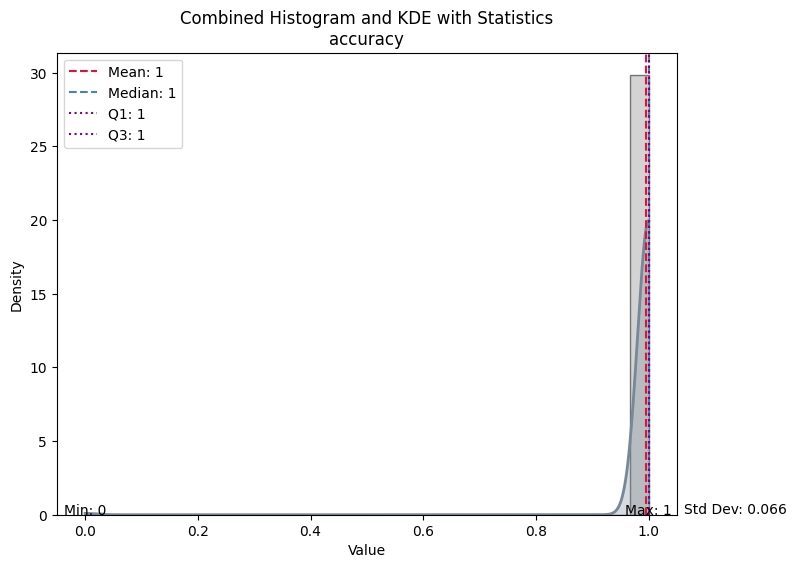

,Value
accuracy,
Mean,0.995589
Median,1.000000
Standard Deviation,0.066265
Min,0.000000
Max,1.000000
Q1,1.000000
Q3,1.000000


In [ ]:
# test_data = test_biodataloader(data, test_ds) # type:ignore
evaluate_classification_model(trainer, metrics=accuracy, show_graph=True, show_results=True);